In [3]:
import evlicious
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import tqdm
import h5py
import numpy as np
import os
import yaml


accuracy = 1e9
dataset = "/data/storage/pellerito/MoonLanding/Malapert_crater/Cam2"
image_files = sorted(Path(dataset + "/image_left").glob("*.png"))
events_file = dataset + "/events.h5"
indices_file = dataset + "/indices.txt"
fps = 5
os.mkdir("/home/pellerito/Automatic_dataset_conversion/plots")

# Plotting events on top

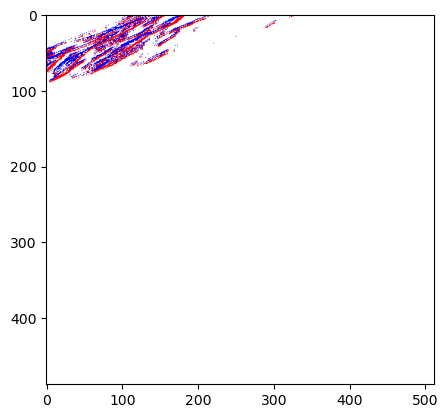

In [4]:
events = evlicious.io.load_events_from_path(Path(events_file))
i0, i1 = np.loadtxt(indices_file, delimiter=",").astype(int)

for num, image_ in enumerate(image_files):
    plt.clf()
    image = cv2.imread(str(image_))
    i_start = i0[num]
    i_stop = i1[num]
    #i_start = i_stop-600000
    new_events = events.get_between_idx(i_start, i_stop)
    #rendered = new_events.render(image)
    rendered = new_events.render(np.ones_like(image)*255)
    plt.imshow(rendered)
    plt.savefig("/home/pellerito/Automatic_dataset_conversion/plots/rendered_{:05d}.png".format(num))
